# Word Frequency Over Time 
Objective: To examine whether the frequency of the terms ‘job’ and ‘immigration’ in SOTU data after 1950 has generally increased or decreased by year.
## Load Data

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import spacy
from spacy import displacy
nlp = spacy.load("en_core_web_sm")

plt.style.use('seaborn-v0_8-dark')

sou = pd.read_csv("data/SOTU.csv")
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


In [2]:
sou_1950 = sou[sou["Year"] >= 1950].copy()
sou_1950["Year"] = sou_1950["Year"].astype(int)
sou_1950["Year"].min(), sou_1950["Year"].max()

(np.int64(1950), np.int64(2024))

In [3]:
target_words = ["job", "immigration"] 

def count_targets_by_year(df, targets):
    records = []
    for year in sorted(df["Year"].unique()):
        df_year = df[df["Year"] == year]
        texts = df_year["Text"].tolist()
        docs = list(nlp.pipe(texts))

        lemmas = [
            tok.lemma_.lower()
            for doc in docs
            for tok in doc
            if not tok.is_stop and not tok.is_punct and not tok.is_space
        ]
        counter = Counter(lemmas)

        for w in targets:
            records.append({
                "Year": int(year),
                "Word": w,
                "Count": counter[w]
            })
    return pd.DataFrame(records)


In [4]:
freq_df = count_targets_by_year(sou_1950, target_words)
freq_df.head()

,Year,Word,Count
0,1950,job,0
1,1950,immigration,0
2,1951,job,4
3,1951,immigration,0
4,1952,job,8


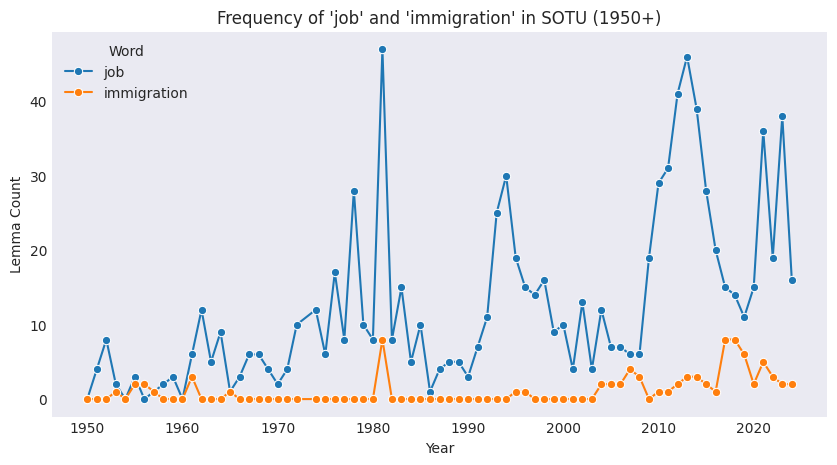

<Figure size 640x480 with 0 Axes>

In [5]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=freq_df, x="Year", y="Count", hue="Word", marker="o")
plt.title("Frequency of 'job' and 'immigration' in SOTU (1950+)")
plt.ylabel("Lemma Count")
plt.xlabel("Year")
plt.show()
plt.savefig("outputs/frequency of 'job' and 'immigratino' in sotu (1950+)", dpi=150, bbox_inches="tight")

Conclusion: In SOTU since 1950, the frequency of the terms "job" and "immigration" has generally increased: "Job" was frequently mentioned from the beginning, and became even more frequent in the 1980s and after 2010; while "immigration" was almost never mentioned in the first few decades, only becoming an increasingly important topic in the last two or three decades.